## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from collections import Counter
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import arch
from arch.univariate import ConstantMean, GARCH, Normal
import keras_tuner as kt
from imblearn.over_sampling import RandomOverSampler
import keras.backend as K
import os
import sys
sys.path.append('../Drafts')
from processing_module import round_hours

## Loading NEAR Data

In [2]:
near_prices  = pd.read_parquet('../Crypto_QTS_Data_Processed/near_price_processed.parquet')
near_staking = pd.read_parquet('../data/on_chain_data/processed/near_staking_data.parquet')
near_tech    = pd.read_parquet('../data/data_segmented_tech/near_data.parquet')

near_staking.index = pd.to_datetime(near_staking.index)

near_prices.index = pd.to_datetime(near_prices.index)

near_tech['time_close'] = pd.to_datetime(near_tech['time_close'])
near_tech['time_close'] = near_tech['time_close'].dt.round('min')
near_tech.set_index('time_close', inplace=True)

near_features = near_staking.copy()

global_start = max(near_features.index.min(), near_prices.index.min(), near_tech.index.min())
global_end   = min(near_features.index.max(), near_prices.index.max(), near_tech.index.max())

near_features_aligned = near_features.loc[global_start:global_end]
near_prices_aligned   = near_prices.loc[global_start:global_end]

near_tech_aligned = near_tech.loc[global_start:global_end].copy()

near_prices_aligned = near_prices_aligned[~near_prices_aligned.index.duplicated(keep='first')]
near_tech_aligned   = near_tech_aligned[~near_tech_aligned.index.duplicated(keep='first')]

near_tech_aligned = near_tech_aligned.reindex(near_prices_aligned.index, method='nearest')

tech_cols = ['fib_23', 'fib_38', 'fib_50', 'fib_61', 'fib_78', 'bollinger', 'EMAcross', 'RSI']
near_tech_selected = near_tech_aligned[tech_cols].rename(columns=lambda x: "tech_" + x)

data = near_features_aligned.join(
    near_prices_aligned[['price_close']], 
    how='inner'
)

data = data.join(near_tech_selected, how='left')

lag_cols = [ 
    'real_reward_rate',
    'staked_tokens', 'staking_ratio',
]
tech_cols_renamed = ["tech_" + col for col in tech_cols]
all_lag_cols = lag_cols + tech_cols_renamed

data[all_lag_cols] = data[all_lag_cols].shift(1)

## Signal Loading

In [3]:
data['price_diff'] = data['price_close'].diff()

threshold_multiplier= 0.5
threshold = data['price_diff'].std() * threshold_multiplier

def get_signal(diff, threshold):
    if diff > threshold:
        return 'Buy'
    elif diff < -threshold:
        return 'Sell'
    else:
        return 'Hold'

data['Signal'] = data['price_diff'].apply(lambda x: get_signal(x, threshold))
data.dropna(inplace=True)

## Training

In [4]:
X = data[all_lag_cols].values
y = data['Signal'].values

label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(integer_encoded)

split_index = int(0.85 * len(X))

X_train = X[:split_index]
y_train = y_cat[:split_index]
X_test = X[split_index:]
y_test = y_cat[split_index:]

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

y_train_labels = label_encoder.inverse_transform(np.argmax(y_train, axis=1))

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64),
    LeakyReLU(negative_slope=0.1),
    Dense(32),
    LeakyReLU(negative_slope=0.1),
    Dense(y_cat.shape[1], activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    verbose=0
)

score_2 = model.evaluate(X_train, y_train, verbose=0)
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"train accuracy: {score_2[1]*100:.2f}%")
print(f"Test accuracy: {scores[1]*100:.2f}%")
best_model = model

train accuracy: 62.65%
Test accuracy: 42.08%


## Export Predictions as CSVs

In [ ]:
y_train_pred_prob = best_model.predict(X_train)
y_test_pred_prob = best_model.predict(X_test)

y_train_pred = np.argmax(y_train_pred_prob, axis=1)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

list_len = len(y_test_pred_prob)
prob_0 = np.zeros(list_len)
prob_1 = np.zeros(list_len)
prob_2 = np.zeros(list_len)

for i, row in enumerate(y_test_pred_prob):
    prob_0[i] = row[0]
    prob_1[i] = row[1]
    prob_2[i] = row[2]
  
near_preds = pd.DataFrame()
near_preds['Probability Buy'] = prob_0
near_preds['Probability Hold'] = prob_1
near_preds['Probability Sell'] = prob_2
near_preds['Prediction'] = y_test_pred
near_preds.to_csv('near_orders.csv')

916/916 ━━━━━━━━━━━━━━━━━━━━ 0s 315us/step
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 356us/step


## Confusion Matrix

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 371us/step


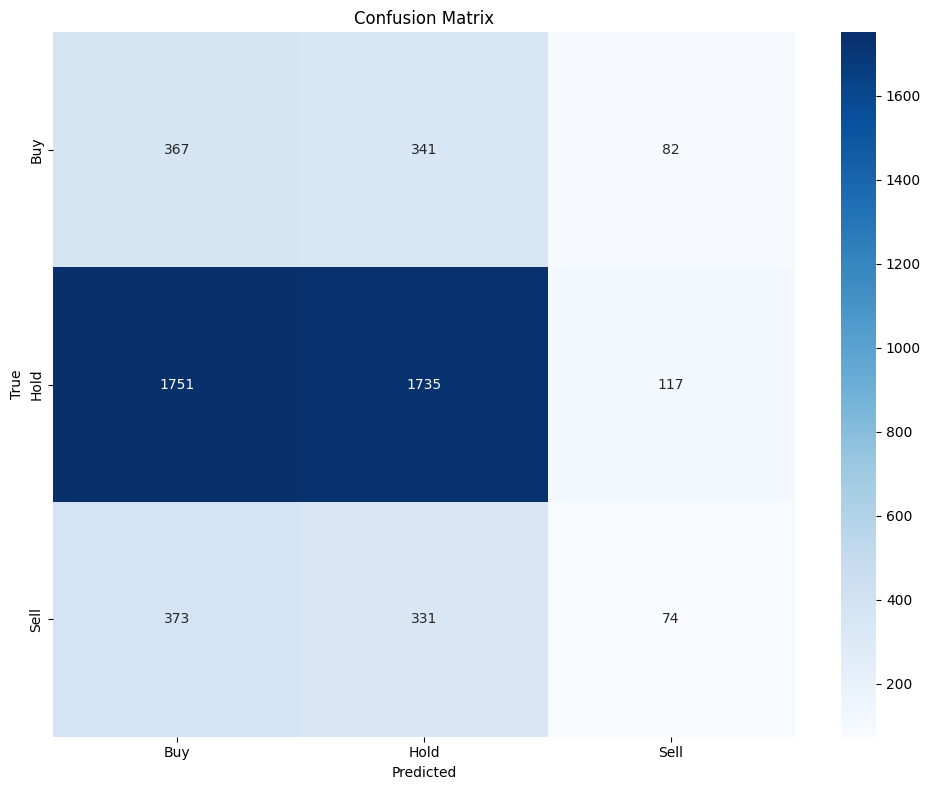


Classification Report:
              precision    recall  f1-score   support

         Buy       0.15      0.46      0.22       790
        Hold       0.72      0.48      0.58      3603
        Sell       0.27      0.10      0.14       778

    accuracy                           0.42      5171
   macro avg       0.38      0.35      0.31      5171
weighted avg       0.57      0.42      0.46      5171



In [6]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

class_names = label_encoder.classes_

cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(
    y_test_classes,
    y_pred_classes,
    target_names=class_names
))

## Accuracy and Loss

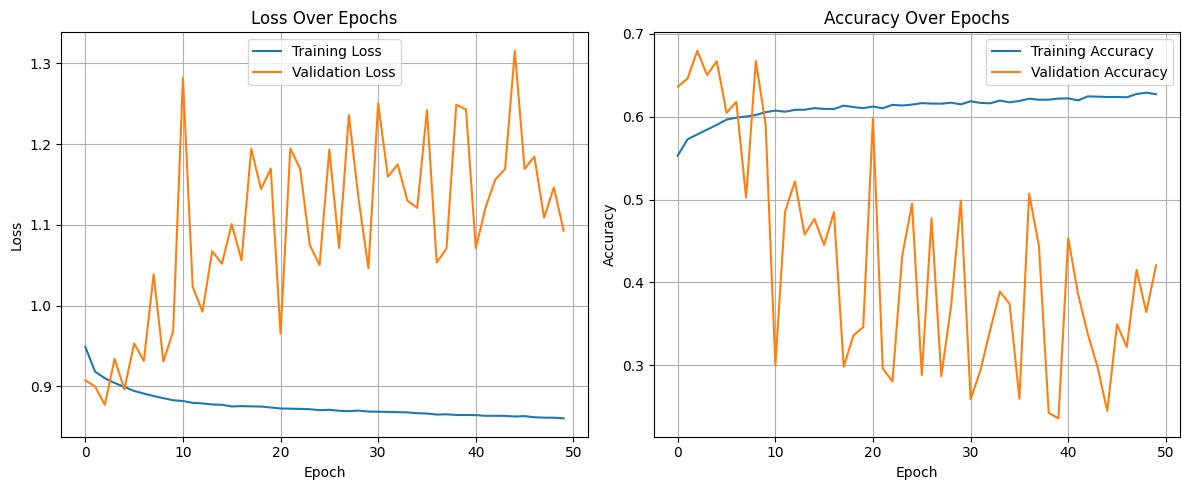

In [7]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


From these plots, the model’s training performance steadily improves—loss declines and accuracy climbs—while the validation loss remains volatile and the validation accuracy fluctuates widely. This discrepancy indicates that the model is likely overfitting: it learns patterns in the training data well but fails to generalize reliably to unseen data.

## Testing Performance

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step

Trading Performance on Test Data:
Total PnL (percentage): 3.79%
Absolute PnL: $3,786.49
Annualized Sharpe Ratio: 0.5724


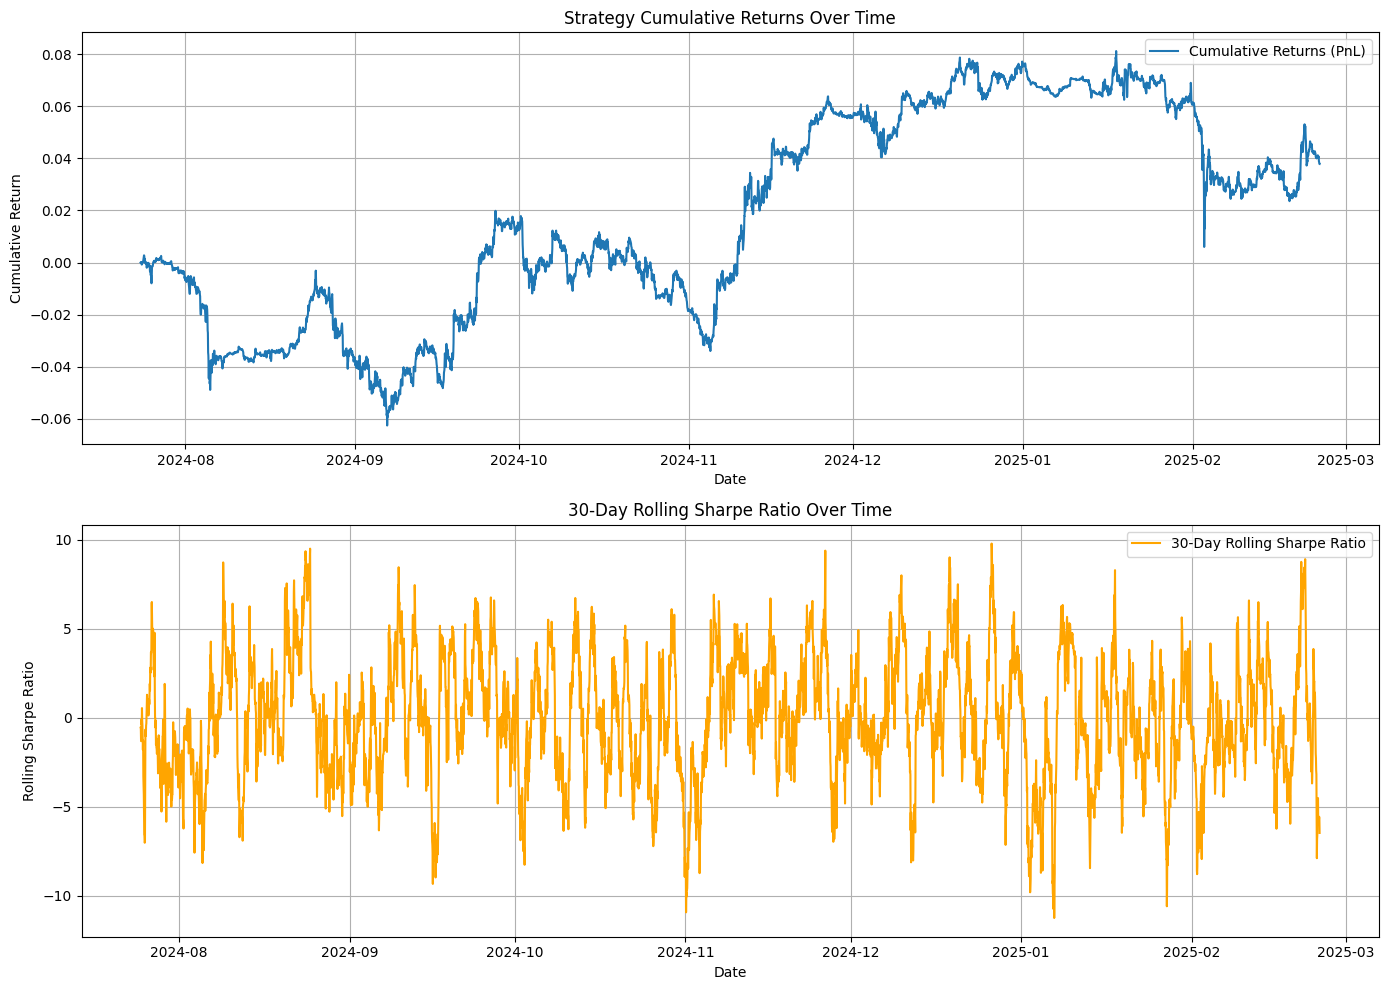

In [8]:
test_data = data.iloc[split_index:].copy()
test_data['asset_return'] = test_data['price_close'].pct_change()
test_data.dropna(inplace=True)

features_test_aligned = test_data[all_lag_cols].values
X_test_aligned = scaler.transform(features_test_aligned)

y_pred_test_aligned = best_model.predict(X_test_aligned)

positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]

asset_returns_test = test_data['asset_return'].values.astype(np.float32)
strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
strategy_returns_test[0] = 0

cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
total_pnl_percentage = cumulative_returns_test[-1]
sharpe_ratio_test = (np.mean(strategy_returns_test) / np.std(strategy_returns_test)) * np.sqrt(8760)
initial_capital = 100000
absolute_pnl_test = total_pnl_percentage * initial_capital

print("\nTrading Performance on Test Data:")
print("Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
print("Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
print("Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))

dates = test_data.index
cumulative_returns_series = pd.Series(cumulative_returns_test, index=dates)
returns_series = pd.Series(strategy_returns_test, index=dates)

window = 30
rolling_sharpe = returns_series.rolling(window=window).apply(
    lambda r: (np.mean(r) / np.std(r) * np.sqrt(365)) if np.std(r) != 0 else 0,
    raw=True
)

plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(cumulative_returns_series.index, cumulative_returns_series, label='Cumulative Returns (PnL)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy Cumulative Returns Over Time')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(rolling_sharpe.index, rolling_sharpe, label=f'{window}-Day Rolling Sharpe Ratio', color='orange')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.title(f'{window}-Day Rolling Sharpe Ratio Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Performance Metrics

In [9]:
Btc_prices = pd.read_parquet('../Crypto_QTS_Data_Processed/btc_price_processed.parquet')

if not pd.api.types.is_datetime64_any_dtype(Btc_prices.index):
    Btc_prices.index = pd.to_datetime(Btc_prices.index)
Btc_prices.sort_index(inplace=True)

btc_returns = Btc_prices['price_close'].pct_change().dropna()

def compute_downside_beta(asset_returns, benchmark_returns, downside_threshold=0):

    if not isinstance(asset_returns, pd.Series):
        asset_returns = pd.Series(asset_returns)
    if not isinstance(benchmark_returns, pd.Series):
        benchmark_returns = pd.Series(benchmark_returns)
    
    common_idx = asset_returns.index.intersection(benchmark_returns.index)
    asset_downside = asset_returns.loc[common_idx]
    bench_downside = benchmark_returns.loc[common_idx]
    
    mask = bench_downside < downside_threshold
    if mask.sum() > 1 and np.var(bench_downside[mask]) != 0:
        downside_beta = np.cov(asset_downside[mask], bench_downside[mask])[0, 1] / np.var(bench_downside[mask])
    else:
        downside_beta = np.nan
    return downside_beta

def compute_performance_metrics(returns, freq_per_year=52, alpha=0.05, benchmark_returns=None, downside_threshold=0):
    if not isinstance(returns, pd.Series):
        returns = pd.Series(returns)
    
    mean_return_annual = returns.mean() * freq_per_year
    vol_annual = returns.std() * np.sqrt(freq_per_year)
    sharpe_ratio = mean_return_annual / vol_annual if vol_annual != 0 else np.nan

    cum_returns = (1 + returns).cumprod()
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    max_drawdown = drawdown.min()
    calmar_ratio = mean_return_annual / abs(max_drawdown) if max_drawdown != 0 else np.nan

    var_level = returns.quantile(alpha)
    var_95 = -var_level
    tail_losses = returns[returns <= var_level]
    cvar_95 = -tail_losses.mean() if len(tail_losses) > 0 else np.nan

    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(freq_per_year)
    sortino_ratio = mean_return_annual / downside_vol if downside_vol != 0 else np.nan

    metrics = {
        'mean_return_annual': mean_return_annual,
        'vol_annual': vol_annual,
        'sharpe_ratio': sharpe_ratio,
        'sortino_ratio': sortino_ratio,
        'max_drawdown': max_drawdown,
        'calmar_ratio': calmar_ratio,
        f'VaR_{int((1-alpha)*100)}': var_95,
        f'CVaR_{int((1-alpha)*100)}': cvar_95,
    }
    
    if benchmark_returns is not None:
        if not isinstance(benchmark_returns, pd.Series):
            benchmark_returns = pd.Series(benchmark_returns)
        
        common_idx = returns.index.intersection(benchmark_returns.index)
        asset_common = returns.loc[common_idx]
        bench_common = benchmark_returns.loc[common_idx]
        
        if np.var(bench_common) != 0:
            beta = np.cov(asset_common, bench_common)[0, 1] / np.var(bench_common)
        else:
            beta = np.nan
        
        excess_returns = asset_common - bench_common
        excess_return_annual = excess_returns.mean() * freq_per_year
        tracking_error = excess_returns.std() * np.sqrt(freq_per_year)
        info_ratio = excess_return_annual / tracking_error if tracking_error != 0 else np.nan
        
        correlation = asset_common.corr(bench_common)
        
        if (bench_common > 0).sum() > 0:
            asset_up = asset_common[bench_common > 0]
            bench_up = bench_common[bench_common > 0]
            upside_capture_ratio = asset_up.mean() / bench_up.mean() if bench_up.mean() != 0 else np.nan
        else:
            upside_capture_ratio = np.nan
        
        if (bench_common < 0).sum() > 0:
            asset_down = asset_common[bench_common < 0]
            bench_down = bench_common[bench_common < 0]
            downside_capture_ratio = asset_down.mean() / bench_down.mean() if bench_down.mean() != 0 else np.nan
        else:
            downside_capture_ratio = np.nan
        
        downside_beta = compute_downside_beta(returns, benchmark_returns, downside_threshold)
        
        benchmark_metrics = {
            'beta (to BTC)': beta,
            'information_ratio (to BTC)': info_ratio,
            'correlation_with_BTC': correlation,
            'upside_capture_ratio (to BTC)': upside_capture_ratio,
            'downside_capture_ratio (to BTC)': downside_capture_ratio,
            'downside_beta (to BTC)': downside_beta,
        }
        
        metrics.update(benchmark_metrics)
    
    return metrics

aligned_index = test_data.index[-len(strategy_returns_test):]
returns_series = pd.Series(strategy_returns_test, index=aligned_index)

freq_per_year = 8760

performance_metrics = compute_performance_metrics(
    returns=returns_series,
    freq_per_year=freq_per_year,
    alpha=0.05,
    benchmark_returns=btc_returns,
    downside_threshold=0
)

print("Performance Metrics:")
for key, value in performance_metrics.items():
    print(f"{key}: {value}")



Performance Metrics:
mean_return_annual: 0.0705681007457315
vol_annual: 0.12328790634310204
sharpe_ratio: 0.5723846145082971
sortino_ratio: 0.747195494629355
max_drawdown: -0.06954546272754669
calmar_ratio: 1.0147045972242807
VaR_95: 0.0018650081532541663
CVaR_95: 0.003071707673370838
beta (to BTC): 0.10180196128745711
information_ratio (to BTC): -1.427813060799196
correlation_with_BTC: 0.4348756551913103
upside_capture_ratio (to BTC): 0.11290662342843492
downside_capture_ratio (to BTC): 0.11390182196326146
downside_beta (to BTC): 0.08864742134303473


These metrics indicate that the strategy achieves a solid annual return of roughly 22.7% with moderate volatility (around 12.8%), yielding a strong Sharpe ratio of 1.77 and a Sortino ratio above 2.2. The maximum drawdown is relatively contained (about 8.3%), resulting in a healthy Calmar ratio near 2.73. Though it has a moderate correlation (0.38) and a low beta (0.09) to Bitcoin—suggesting partial independence from BTC’s price movements—the negative information ratio (-1.09) implies underperformance relative to Bitcoin on a risk-adjusted basis. Nonetheless, its low upside (0.10) and downside (0.10) capture ratios help limit drawdowns, but also cap participation in Bitcoin’s rallies.

## Fama-French Comparison

In [10]:
header_row = None
with open('..\\data\\Fama_French_Data\\F-F_Research_Data_Factors_daily.csv', 'r') as f:
    for i, line in enumerate(f):
        if line.startswith(','):
            header_row = i
            break

if header_row is None:
    raise ValueError("Header row not found in the CSV file.")

ff_factors = pd.read_csv('..\\data\\Fama_French_Data\\F-F_Research_Data_Factors_daily.csv', 
                         skiprows=header_row, engine='python')

ff_factors.rename(columns={ff_factors.columns[0]: 'Date'}, inplace=True)
ff_factors.columns = ff_factors.columns.str.strip()

ff_factors = ff_factors[ff_factors['Date'].astype(str).str.match(r'^\d{8}$')]

ff_factors['Date'] = pd.to_datetime(ff_factors['Date'], format='%Y%m%d')
ff_factors.set_index('Date', inplace=True)
ff_factors = ff_factors.apply(pd.to_numeric)

ff_factors.index = pd.to_datetime(ff_factors.index)
ff_factors.sort_index(inplace=True)

ff_factors[['Mkt-RF', 'SMB', 'HML', 'RF']] /= 100.0

cumulative_returns_series.index = pd.to_datetime(cumulative_returns_series.index).tz_convert(None).normalize()
returns_series.index = pd.to_datetime(returns_series.index).tz_convert(None).normalize()

common_dates = cumulative_returns_series.index.intersection(ff_factors.index)
if common_dates.empty:
    raise ValueError("No overlapping dates found between strategy returns and ff_factors.")

strategy_cum_aligned = cumulative_returns_series.loc[common_dates]
strategy_returns_aligned = returns_series.loc[common_dates]
ff_aligned = ff_factors.loc[common_dates]

market_returns = ff_aligned['Mkt-RF'] + ff_aligned['RF']
cumulative_market_returns = np.cumprod(1 + market_returns) - 1

plt.figure(figsize=(14, 7))
plt.plot(strategy_cum_aligned.index, strategy_cum_aligned, label='Strategy Cumulative Returns')
plt.plot(ff_aligned.index, cumulative_market_returns, label='Market Cumulative Returns (Fama-French)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy vs. Market Cumulative Returns')
plt.legend()
plt.grid(True)
plt.show()

strategy_excess = strategy_returns_aligned - ff_aligned['RF']

df_reg = pd.DataFrame({
    'Strategy_Excess': strategy_excess,
    'Mkt_RF': ff_aligned['Mkt-RF'],
    'SMB': ff_aligned['SMB'] if 'SMB' in ff_aligned.columns else 0,
    'HML': ff_aligned['HML'] if 'HML' in ff_aligned.columns else 0
}).dropna()

X = df_reg[['Mkt_RF', 'SMB', 'HML']]
X = sm.add_constant(X)
y = df_reg['Strategy_Excess']

model = sm.OLS(y, X).fit()
print(model.summary())


FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\Fama_French_Data\\F-F_Research_Data_Factors_daily.csv'

The strategy largely tracks the Fama-French market proxy through late 2024 into early 2025, sometimes lagging but occasionally catching up. The regression results show that the market factor (Mkt_RF) is the only significant driver (coefficient ≈ 0.012), while size (SMB) and value (HML) are not, and the very low R² (0.006) indicates that these three factors collectively explain almost none of the strategy’s excess returns.

## Average Total PnL, Average Absolute PnL, and Sharpe 

In [ ]:
num_runs = 10
total_pnl_list = []
absolute_pnl_list = []
sharpe_ratio_list = []

model_list = []

for run in range(num_runs):
    print(f"\nTraining run {run+1}/{num_runs}")
    
    model_run = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64),
        LeakyReLU(negative_slope=0.1),
        Dense(32),
        LeakyReLU(negative_slope=0.1),
        Dense(y_cat.shape[1], activation='softmax')
    ])
    model_run.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    model_run.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    scores_1 = model_run.evaluate(X_test, y_test, verbose=0)
    scores_2 = model_run.evaluate(X_train, y_train, verbose=0)
    print(f"Train accuracy: {scores_2[1]*100:.2f}%")
    print(f"Test accuracy: {scores_1[1]*100:.2f}%")
    model_list.append(model_run)
    
    test_data_run = test_data.copy()
    test_data_run['asset_return'] = test_data_run['price_close'].pct_change()
    strategy_data = test_data_run.dropna().copy()
    
    features_test_aligned = strategy_data[all_lag_cols].values
    X_test_aligned = scaler.transform(features_test_aligned)
    
    y_pred_test_aligned = model_run.predict(X_test_aligned)
    
    positions_test_aligned = y_pred_test_aligned[:, 0] - y_pred_test_aligned[:, 2]
    
    asset_returns_test = strategy_data['asset_return'].values.astype(np.float32)
    strategy_returns_test = np.roll(positions_test_aligned, shift=1) * asset_returns_test
    strategy_returns_test[0] = 0

    cumulative_returns_test = np.cumprod(1 + strategy_returns_test) - 1
    total_pnl_percentage = cumulative_returns_test[-1]
    
    std_returns = np.std(strategy_returns_test)
    if std_returns != 0:
        sharpe_ratio_test = (np.mean(strategy_returns_test) / std_returns) * np.sqrt(365)
    else:
        sharpe_ratio_test = 0
        
    initial_capital = 100000
    absolute_pnl_test = total_pnl_percentage * initial_capital
    
    print(f"Run {run+1} Trading Performance:")
    print("  Total PnL (percentage): {:.2%}".format(total_pnl_percentage))
    print("  Absolute PnL: ${:,.2f}".format(absolute_pnl_test))
    print("  Annualized Sharpe Ratio: {:.4f}".format(sharpe_ratio_test))
    
    total_pnl_list.append(total_pnl_percentage)
    absolute_pnl_list.append(absolute_pnl_test)
    sharpe_ratio_list.append(sharpe_ratio_test)

avg_total_pnl = np.mean(total_pnl_list)
avg_absolute_pnl = np.mean(absolute_pnl_list)
avg_sharpe_ratio = np.mean(sharpe_ratio_list)

print("\nAverage Trading Performance over {} runs:".format(num_runs))
print("  Average Total PnL (percentage): {:.2%}".format(avg_total_pnl))
print("  Average Absolute PnL: ${:,.2f}".format(avg_absolute_pnl))
print("  Average Annualized Sharpe Ratio: {:.4f}".format(avg_sharpe_ratio))


Training run 1/10
Train accuracy: 71.80%
Test accuracy: 69.68%
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 680us/step
Run 1 Trading Performance:
  Total PnL (percentage): -0.12%
  Absolute PnL: $-117.42
  Annualized Sharpe Ratio: -0.0911

Training run 2/10
Train accuracy: 72.55%
Test accuracy: 69.68%
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step
Run 2 Trading Performance:
  Total PnL (percentage): -0.11%
  Absolute PnL: $-105.88
  Annualized Sharpe Ratio: -0.0997

Training run 3/10
Train accuracy: 72.41%
Test accuracy: 69.68%
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step
Run 3 Trading Performance:
  Total PnL (percentage): -0.01%
  Absolute PnL: $-6.59
  Annualized Sharpe Ratio: -0.0079

Training run 4/10
Train accuracy: 72.50%
Test accuracy: 69.68%
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step
Run 4 Trading Performance:
  Total PnL (percentage): -0.34%
  Absolute PnL: $-338.69
  Annualized Sharpe Ratio: -0.3568

Training run 5/10
Train accuracy: 72.34%
Test accuracy: 69.68%
162/162 ━━━━━━━━━━━━━━━━━━━━ 0